# Правила

**Даты**: 22.12.2024 - 28.12.2024

**Дедлайн**: 28.12.2024 23:59

**Отправка после дедлайна**: НЕВОЗМОЖНА


За каждое задание вы получите определенное количество баллов (указано в скобках рядом с каждым заданием). Максимальная оценка за работу - 10 баллов.

* **Задания, где вы должны написать код**, помечены 🐴 (эмодзи лошади).

* **Вопросы, на которые вы должны дать ответ текстом**, помечены знаком ❓ (эмодзи вопроса).

Вы также увидите код "assert", этот код должен вам помочь: если вы все делаете правильно - код не выдаст ошибку AssertionError.

**Дисклеймер**: экзамен должен выполняться самостоятельно. "Очень похожие" решения считаются плагиатом, и все зайдествованные студенты (включая тех, у кого работа была скопирована) получают 0 баллов за экзамен.

# Подготовка

Обратите внимание, что вам необходимо импортировать дополнительные библиотеки и модули для решения.

In [267]:
pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [268]:
pip install prophet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [269]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализации
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp
from statsmodels.tsa.seasonal import MSTL as MSTL_decomp

# Модель Prophet
import prophet as fp

# Тюнинг
import itertools

In [270]:
!pip install pmdarima

# авто ARIMA
from pmdarima import auto_arima


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [271]:
!pip install statsforecast

# MSTL
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL
  )


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [272]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [273]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [274]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())


# Описание задачи

Вы будете работать над прогнозированием показателей *BookBnb*, платформы краткосрочной аренды, которую любят путешественники за ее услуги и качество объектов недвижимости. Вы будете прогнозировать метрику **просмотров** для объявлений (=объектов недвижимости) из *Калининграда*, представленных на платформе.

Метрика **просмотров** показывает, сколько раз пользователи просматривали объявление о недвижимости на платформе. Она служит показателем интереса или спроса к конкретному объекту недвижимости или месту назначения (например, городу). Этот показатель имеет решающее значение для понимания вовлеченности пользователей, привлекательности объявлений и общей активности на платформе. Таким образом, количество просмотров в Калининграде отражает уровень интереса к этому региону, что делает его ключевым показателем для оценки его популярности и потенциала для дальнейших инвестиций.

Основная цель - оценить популярность Калининграда как туристического направления на платформе и определить, стоит ли инвестировать в рекламные объекты в этом регионе. Ваш прогноз поможет BookBnb принимать стратегические решения о распределении ресурсов и маркетинговых кампаниях для стимулирования роста и улучшения взаимодействия с пользователями.

Ваша цель - составить надежный прогноз на следующий год и доказать, что компания может ему доверять. Этот прогноз послужит основой для принятия обоснованных решений на конкурентном рынке аренды. Удачи! 🚀

Обратите внимание на горизонт прогноза: ваша последняя задача - спрогнозировать один будущий год.

In [275]:
FORECAST_HORIZON = 365

# Данные

Вы можете загрузить датасет *exam_views_kgd.csv* с временными рядами метрики *просмотров* по [ссылке](https://drive.google.com/file/d/1XRh0JKvFGtNjOJXG4_qZBDWX9R5FXldb/view?usp=sharing).

Датасет включает исторические данные **с начала 2019 года по конец 2022 года** (представьте, что сейчас 2022 год :D).

**Колонки:**

* *region* - регион, в котором присутствуют объекты недвижимости, в этом датасете есть только "Kaliningrad".;

* *dt* - даты, подневно, без пропусков;

* *metric* - название метрики, в этом датасете есть только "views";

* *value* - значение метрики.

In [276]:
df = pd.read_csv('exam_views_kgd.csv', sep=';', parse_dates=['dt'])
df

,region,dt,metric,value
0,Kaliningrad,2019-01-01,views,26011.0
1,Kaliningrad,2019-01-02,views,23158.0
2,Kaliningrad,2019-01-03,views,23413.0
3,Kaliningrad,2019-01-04,views,22534.0
4,Kaliningrad,2019-01-05,views,21431.0
...,...,...,...,...
1456,Kaliningrad,2022-12-27,views,23796.0
1457,Kaliningrad,2022-12-28,views,22762.0
1458,Kaliningrad,2022-12-29,views,20338.0
1459,Kaliningrad,2022-12-30,views,10723.0


Let's plot the time series.

In [277]:
fig = px.line(title="BookBnb views for listings from Kaliningrad, daily")
fig.add_scatter(x=df.dt, y=df['value'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

Переименуем колонки для дальнейшей работы.

In [278]:
df.columns = ['region', 'ds', 'metric', 'y']

df

,region,ds,metric,y
0,Kaliningrad,2019-01-01,views,26011.0
1,Kaliningrad,2019-01-02,views,23158.0
2,Kaliningrad,2019-01-03,views,23413.0
3,Kaliningrad,2019-01-04,views,22534.0
4,Kaliningrad,2019-01-05,views,21431.0
...,...,...,...,...
1456,Kaliningrad,2022-12-27,views,23796.0
1457,Kaliningrad,2022-12-28,views,22762.0
1458,Kaliningrad,2022-12-29,views,20338.0
1459,Kaliningrad,2022-12-30,views,10723.0


# 1 - Предобработка

Мы всегда должны начинать с предварительной обработки. Реальные данные могут содержать nan, аномалии и другие проблемы.

Для нашей задачи мы поработаем с nan.

## Задание 1.1 - Заполнение nan (0,5 балла)

🐴 **Найдите nan в датасете и заполните nan, используя подходящий метод.**

In [279]:
print(df.isna().sum())
df['y'] = df['y'].interpolate(method='linear')
assert df.isna().sum().sum() == 0

region     0
ds         0
metric     0
y         76
dtype: int64


Нарисуем график временного ряда с заполненными nan.

In [280]:
fig = px.line(title="BookBnb views for listings from Kaliningrad, daily")
fig.add_scatter(x=df.ds, y=df['y'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

❓ **Почему вы выбрали этот способ заполнения nan? Напишите свои комментарии ниже:**


Я выбрала **линейную интерполяцию**, потому что работаю с дневным временным рядом, где пропуски чаще всего связаны с особенностями сбора/логирования данных, а не с реальным обнулением метрики. Линейная интерполяция восстанавливает значения между соседними наблюдениями, сохраняя общую динамику ряда и не создавая искусственных скачков, как это может происходить при заполнении средним или медианой.

Также для дальнейшего моделирования (Prophet / ARIMA / MSTL) важно иметь непрерывный ряд без пропусков, иначе модели могут обучаться некорректно. Поскольку пропуски в данных были короткими, линейная интерполяция является обоснованным решением. Если бы пропуски были длинными, я бы рассматривала сезонное заполнение или отдельную модель для восстановления.





In [281]:
# проверка, что все ок
assert df.isna().sum().sum() == 0

# 2 - Регрессоры

Чтобы повысить точность вашего прогноза, вы будете использовать регрессоры, как фиктивные, так и непрерывные. Используя эти факторы, вы сможете лучше учитывать внешние события и тенденции, которые влияют на поведение пользователей на платформе.


Для решения этой задачи вы будете учитывать следующие регрессоры:

* **COVID-19**: период пандемии должен был повлиять на поведение путешественников и интерес к краткосрочной аренде жилья.

* **Введение новой фичи продукта**: в начале 2022 года на платформе был представлен новый алгоритм поиска, который, возможно, повлиял на вовлеченность пользователей.

* **DAU** (Ежедневные активные пользователи) платформы: общее количество активных пользователей на платформе каждый день, которое дает представление об общей активности и вовлеченности пользователей.

Эти регрессоры помогут вам охватить более широкий контекст и основные факторы, влияющие на метрику просмотров (views), что сделает ваш прогноз более надежным и содержательным.

В результате выполнения этой части экзамена вы создадите 2 датафрейма:

* **regressors** - датафрйем с вашими регрессорами за период вашего вр. ряда (с 2019 по конец 2022 года);
* **regressors_future** - датафрйем с вашими регрессорами для будущих дат (будущие *FORECAST_HORIZON* дней).

In [ ]:
# Создание датафрейма regressors
regressors = pd.DataFrame()
regressors['ds'] = df.ds
regressors

,ds
0,2019-01-01
1,2019-01-02
2,2019-01-03
3,2019-01-04
4,2019-01-05
...,...
1456,2022-12-27
1457,2022-12-28
1458,2022-12-29
1459,2022-12-30


In [ ]:
# Создание датафрейма regressors_future
regressors_future = pd.DataFrame()
regressors_future['ds'] = pd.date_range(start=df.ds.max()+ np.timedelta64(1, 'D'), periods=FORECAST_HORIZON)
regressors_future

,ds
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
360,2023-12-27
361,2023-12-28
362,2023-12-29
363,2023-12-30


## 2.1 - Dummy регрессоры

Пришло время подготовить dummy регрессоры для COVID-19 и введения новой продуктовой фичи.

### Задание 2.1 - Подготовка dummy регрессоров (1 балл)

1) Давайте возьмем такие даты для COVID-19: с 30 января 2020 года по 5 мая 2023 года.

🐴 **Подготовьте dummy регрессор COVID-19 и добавьте его в датафреймы *regressors* и *regressors_future*.**

In [284]:
covid_start = "2020-01-30"
covid_end   = "2023-05-05"

regressors['ds'] = pd.to_datetime(regressors['ds'])
regressors_future['ds'] = pd.to_datetime(regressors_future['ds'])

regressors['covid'] = ((regressors['ds'] >= covid_start) & (regressors['ds'] <= covid_end)).astype(int)
regressors_future['covid'] = ((regressors_future['ds'] >= covid_start) & (regressors_future['ds'] <= covid_end)).astype(int)


2) Новый алгоритм поиска был добавлен на платформу 1 января 2022.

🐴 **Подготовьте dummy регрессор для новой продуктовой фичи и добавьте его в датафреймы *regressors* и *regressors_future*.**

In [285]:
feature_start = "2022-01-01"

# преобразуем колонку с датами в формат datetime для корректного сравнения дат
regressors['ds'] = pd.to_datetime(regressors['ds'])
regressors_future['ds'] = pd.to_datetime(regressors_future['ds'])

# создаем dummy регрессор 1 для дат >= 2022-01-01, 0 для более ранних дат
regressors['new_feature'] = (regressors['ds'] >= feature_start).astype(int)
regressors_future['new_feature'] = (regressors_future['ds'] >= feature_start).astype(int)

## 2.2 - Непрерывный регрессор DAU

*DAU* должен быть сильным регрессором для прогнозирования *views*, поскольку он отражает общий уровень активности на платформе. Увеличение *DAU* часто указывает на то, что больше пользователей активно используют приложение, что приводит к повышению активности поиска и увеличению количества просмотров объектов недвижимости. Эта связь делает DAU хорошим индикатором спроса и интереса пользователей, улавливающим поведенческие тенденции, такие как всплески во время праздников или после окончания маркетинговых кампаний.

Вы можете загрузить датасет *exam_dau_total.csv* с временными рядами для *DAU* по [ссылке](https://drive.google.com/file/d/11ScbYHtuXlG4siBDw5p9aDN47l6OrMH3/view?usp=sharing).

Набор данных содержит исторические данные **за период с начала 2019 года по конец 2022 года**. Обратите внимание, что это DAU для всей платформы.

**Колонки:**

* *dt* - даты, подневно, без пропусков;

* *metric* - название метрики, в этом датасете есть только "DAU";

* *value* - значение метрики.

In [286]:
reg = pd.read_csv('exam_dau_total.csv', sep=';', parse_dates=['dt'])
reg

,dt,metric,value
0,2019-01-01,DAU,1541086.0
1,2019-01-02,DAU,1766712.0
2,2019-01-03,DAU,1800857.0
3,2019-01-04,DAU,1832445.0
4,2019-01-05,DAU,1871104.0
...,...,...,...
1456,2022-12-27,DAU,2357898.0
1457,2022-12-28,DAU,2305066.0
1458,2022-12-29,DAU,2293198.0
1459,2022-12-30,DAU,2243752.0


Давайте построим график для регрессора.

In [287]:
fig = px.line(title="BookBnb DAU, daily")
fig.add_scatter(x=reg.dt, y=reg['value'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="DAU")
fig.show()

Не забывайте, что обычно вам также приходится предварительно обрабатывать и регрессоры.

🐴 **Проверьте регрессоры на наличие nan и используйте подходящий метод для их заполнения.**

In [288]:
# проверяем наличие NaN в регрессорах
print("Количество NaN значений в регрессорах:")
print(reg.isna().sum())
print(f"\nВсего NaN: {reg.isna().sum().sum()}")

# заполняем NaN с помощью линейной интерполяции
reg['value'] = reg['value'].interpolate(method='linear')

print(f"\nПосле заполнения NaN: {reg.isna().sum().sum()}")

Количество NaN значений в регрессорах:
dt         0
metric     0
value     19
dtype: int64

Всего NaN: 19

После заполнения NaN: 0


Построим график для регрессора *DAU* с заполненными nan.

In [289]:
fig = px.line(title="BookBnb DAU, daily")
fig.add_scatter(x=reg.dt, y=reg['value'], mode='lines')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="DAU")
fig.show()

Основная проблема с этим регрессором заключается в том, что он отражает *DAU* для всей платформы *BookBnb* и является довольно шумным. Так, давайте не будем включать весь временной ряд *DAU*, а выделим тренд и используем его в качестве регрессора.

### Задание 2.2.1 - Определение тренда (0,5 балла)

Компоненты временного ряда могут быть извлечены с помощью соответствующего алгоритма декомпозиции.

🐴 **Извлеките тренд с помощью подходящего метода декомпозиции.**

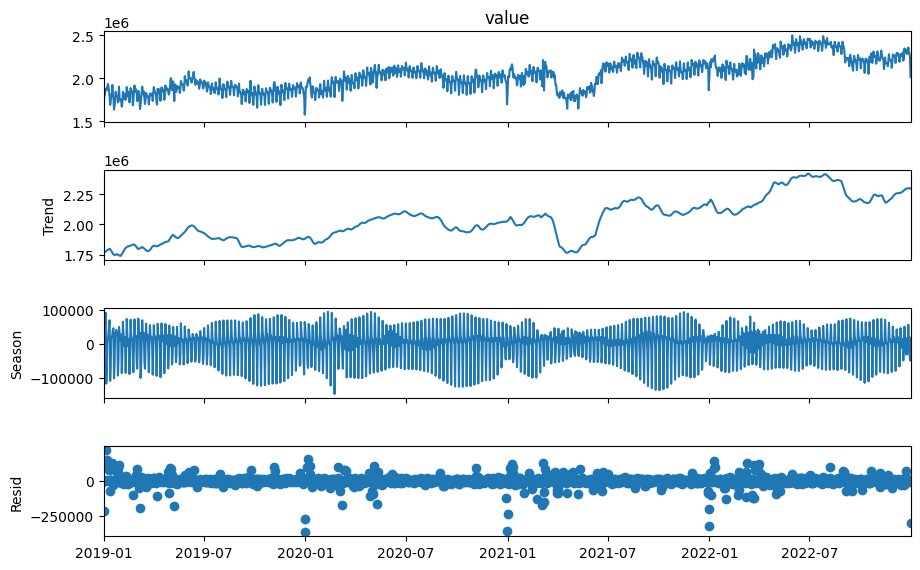

In [290]:
#устанавливаем дату как индекс для декомпозиции
reg_ts = reg.set_index('dt')['value']

# используем STL с периодом 7 дней (недельная сезонность для DAU)
model = STL_decomp(reg_ts, period=7, robust=True)
res = model.fit()


fig = res.plot()
fig.set_size_inches(10, 6)
plt.show()

### STL-декомпозиция DAU: 

На графике показана STL-декомпозиция дневного ряда DAU на компоненты: исходный ряд, тренд, сезонность и остатки. Трендовая компонента показывает плавный рост с 2019 по 2022 год с просадкой в первой половине 2021 года и последующим восстановлением. Выражена недельная сезонность с амплитудой порядка десятков тысяч, что соответствует паттерну будни-выходные. Остатки в основном колеблются вокруг нуля, что означает, что тренд и сезонность хорошо объясняют структуру ряда, хотя присутствуют некоторые выбросы, которые могут быть связаны с разовыми событиями или особенностями данных.


<Axes: title={'center': 'DAU residuals (STL)'}, xlabel='dt'>

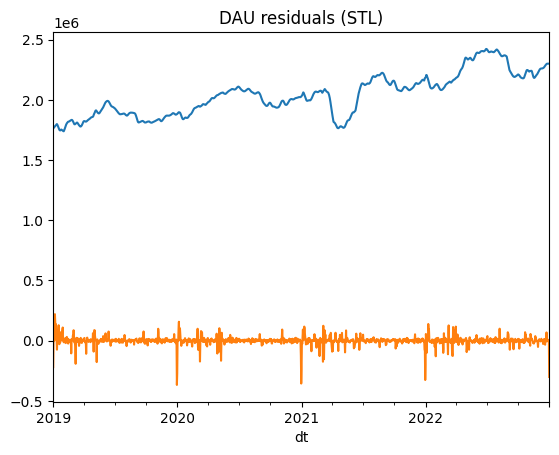

In [291]:
# график тренда и остатков 
# используем res.trend и res.resid напрямую из результата декомпозиции
res.trend.plot(title="DAU trend (STL)")
res.resid.plot(title="DAU residuals (STL)")

❓ **Почему вы выбрали именно этот метод декомпозиции и такую/такие длины сезонного периода/периодов? Напишите свои комментарии ниже:**


Я выбрала STL-декомпозицию и период сезонности 7 дней, потому что STL хорошо подходит для дневных рядов с трендом и живой сезонностью.DAU это типичный дневной ряд: есть долгосрочный тренд (рост/просадки) и регулярный недельный паттерн. STL устойчиво разделяет эти компоненты и не требует жёстких предположений о форме тренда. Период 7 дней это естественная недельная сезонность для DAU. Активность пользователей почти всегда отличается в будни и выходные, поэтому недельный цикл является самым сильным и ожидаемым сезонным эффектом. На графике сезонной компоненты видно регулярное повторение именно с недельной частотой.

Параметр robust=True выбран из-за выбросов. В DAU встречаются аномальные дни (скачки). Robust режим снижает влияние выбросов на оценку тренда и сезонности, делая тренд более чистым.

В задании на этом шаге важнее получить устойчивый тренд и проверить остатки. Недельная сезонность здесь доминирует, поэтому STL с period=7 простой выбор. Если бы требовалось явно учитывать несколько сезонностей (например, 7 и 365), тогда я бы выбрала MSTL.



🐴 **Проанализируйте остатки на автокорреляцию (с помощью 1 теста) и стационарность (с помощью 2 тестов).**

In [ ]:
#подготавливаем остатки для тестирования (удаляем NaN значения)
# используем res.resid из результата декомпозиции
resid_clean = res.resid.dropna()

# тест на автокорреляцию: Ljung-Box test
# H0: нет автокорреляции в остатках
print("ТЕСТ НА АВТОКОРРЕЛЯЦИЮ: Ljung-Box Test")
lb = acorr_ljungbox(resid_clean, lags=[14], return_df=True)
print("\nLjung-Box test (lags=14):")
display(lb)

# тесты на стационарность

# 2.1. ADF test (Augmented Dickey-Fuller)
# H0: ряд имеет unit root (ряд НЕстационарен)
print("ТЕСТ НА СТАЦИОНАРНОСТЬ: ADF Test")
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, adf_icbest = adfuller(resid_clean, autolag='AIC')
print(f"\nADF Test Statistic: {adf_stat:.4f}")
print(f"p-value: {adf_p:.4f}")
print(f"Critical Values:")
for key, value in adf_crit.items():
    print(f"  {key}: {value:.4f}")

# 2.2. KPSS test
# H0: ряд стационарен
print("ТЕСТ НА СТАЦИОНАРНОСТЬ: KPSS Test")
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(resid_clean, regression='c', nlags='auto')
print(f"\nKPSS Test Statistic: {kpss_stat:.4f}")
print(f"p-value: {kpss_p:.4f}")
print(f"Critical Values:")
for key, value in kpss_crit.items():
    print(f"  {key}: {value:.4f}")

ТЕСТ НА АВТОКОРРЕЛЯЦИЮ: Ljung-Box Test

Ljung-Box test (lags=14):


,lb_stat,lb_pvalue
14,303.434394,2.271632e-56


ТЕСТ НА СТАЦИОНАРНОСТЬ: ADF Test

ADF Test Statistic: -10.4769
p-value: 0.0000
Critical Values:
  1%: -3.4349
  5%: -2.8635
  10%: -2.5678
ТЕСТ НА СТАЦИОНАРНОСТЬ: KPSS Test

KPSS Test Statistic: 0.1485
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390


/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_17758/857171050.py:27: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [293]:
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print(f"Автокорреляция (Ljung-Box): {'ЕСТЬ' if lb['lb_pvalue'].iloc[0] < 0.05 else 'НЕТ'}")
print(f"Стационарность (ADF): {'СТАЦИОНАРНЫ' if adf_p < 0.05 else 'НЕстационарны'}")
print(f"Стационарность (KPSS): {'СТАЦИОНАРНЫ' if kpss_p >= 0.05 else 'НЕстационарны'}")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Автокорреляция (Ljung-Box): ЕСТЬ
Стационарность (ADF): СТАЦИОНАРНЫ
Стационарность (KPSS): СТАЦИОНАРНЫ


❓ **Успешна ли ваша декомпозиция судя по остаткам? Каковы могут быть причины такого результата? Напишите свои комментарии ниже:**

Декомпозиция **частично успешна**:
- Остатки стационарны по обоим тестам (ADF и KPSS), что является важным критерием успешной декомпозиции. Это означает, что тренд и сезонность были успешно выделены из исходного ряда, и остатки не содержат долгосрочных трендов или структурных изменений.

- Остатки имеют автокорреляцию (Ljung-Box p-value ≈ 0), что указывает на наличие остаточной структуры в данных.Идеальные остатки должны быть белым шумом (без автокорреляции), что означало бы полное извлечение всей структуры из ряда.

Возможно, в данных присутствуют дополнительные сезонные паттерны (например, месячная или квартальная сезонность), которые не были учтены при использовании только недельной сезонности (period=7). В остатках могут сохраняться нелинейные зависимости между наблюдениями, которые STL не смог полностью извлечь.


🐴 **Сохраните компоненту тренда из вашей декомпозиции в переменную trend_reg.**

In [294]:
# Сохраняем компоненту тренда из STL декомпозиции
# res.trend содержит трендовую компоненту, извлеченную из DAU
trend_reg = res.trend

С помощью приведенного ниже кода вы можете увидеть, как регрессор *тренда DAU* "коррелирует" с временными рядами просмотров.

In [295]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.ds,
    y=df['y'],
    mode='lines',
    name='y',
    line=dict(color='blue'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=trend_reg.index,  # trend_reg - это Series с индексом дат, используем .index
    y=trend_reg,
    mode='lines',
    name='net income',
    line=dict(color='red'),
    yaxis='y2'
))


fig.update_layout(
    title="BookBnb views for listings from Kaliningrad, daily",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='stock prices',
    ),
    yaxis2=dict(
        title='net income',
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Date')
)

fig.show()

### Комментарий
Оба ряда демонстрируют схожую динамику, что указывает на положительную корреляцию между трендом DAU и просмотрами BookBnb. Когда растет активность пользователей (DAU), растут и просмотры объявлений. Оба ряда показывают выраженную сезонность с пиками в летние месяцы (июль-август) и минимумами в зимние месяцы (январь-февраль). Это характерно для туристического бизнеса, где летний период является высоким сезоном. 2019-2020 оба показателя находятся на более низком уровне. 2021 наблюдается рост, особенно заметный в летний период. 2022 достигнуты максимальные значения за весь период наблюдения.

Период 2020-2021 годов (в рамках COVID-19 регрессора) показывает некоторую волатильность, но общий тренд роста сохраняется.

С января 2022 года (введение новой фичи) наблюдается дальнейший рост обоих показателей, достигая пиковых значений в середине 2022 года.

### Выводы:

Тренд DAU является хорошим регрессором для прогнозирования просмотров BookBnb, так как демонстрирует сильную положительную корреляцию. Оба ряда имеют схожую сезонную структуру, что подтверждает их взаимосвязь. Использование тренда DAU (вместо исходного DAU) позволяет исключить сезонные колебания и сосредоточиться на долгосрочной динамике, что делает его более подходящим регрессором для моделей прогнозирования.

### Задание 2.2.2 - Прогнозирование тренда с помощью Auto-ARIMAX (1 балл)

После выделения трендовой составляющей DAU следующим шагом является моделирование и прогнозирование этого тренда на будущие даты.

Поскольку тренды часто демонстрируют автокорреляцию и постепенные изменения во времени, статистическая модель, подобная Auto-ARIMA, хорошо подходит для этой задачи.

Поскольку COVID-19 повлиял на большинство бизнесов, вам также следует добавить dummy регрессор COVID и построить модель Auto-ARIMAX.

🐴 **Постройте модель Auto-ARIMAX (из `pmdarima`), которая учитывает регрессор COVID-19.**

In [ ]:
from pmdarima import auto_arima

# удаляем NaN значения из тренда
series = trend_reg.dropna()

# создаем регрессор COVID-19 для обучающих данных
covid_mask = (series.index >= pd.Timestamp("2020-01-30")) & (series.index <= pd.Timestamp("2023-05-05"))
# преобразуем boolean mask в numpy array нужной формы
X_train = np.array(covid_mask, dtype=int).reshape(-1, 1)

# строим модель Auto-ARIMAX с регрессором COVID-19
# auto_arima автоматически подберет оптимальные параметры (p, d, q)
model = auto_arima(
    series,
    X=X_train,  # экзогенный регрессор COVID-19
    seasonal=False,  # не используем сезонность, так как работаем с трендом
    stepwise=True,  # пошаговый поиск для ускорения
    trace=True  # выводим процесс подбора параметров
)

print(f"\nВыбранные параметры модели: {model.order}")
print(f"Модель: ARIMA{model.order}")
print(f"\nAIC: {model.aic():.2f}")
print(f"BIC: {model.bic():.2f}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=28593.863, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=28582.129, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=28601.928, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=37781.263, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=28568.827, Time=0.25 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=28559.379, Time=0.33 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=28552.694, Time=0.51 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=28548.834, Time=0.53 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=45835.071, Time=0.84 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=45900.537, Time=0.42 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AIC=28550.250, Time=0.62 sec

Best model:  ARIMA(5,1,0)(0,0,0)[0] intercept
Total fit time: 4.298 seconds

Выбранные параметры модели: (5, 1, 0)
Модель: ARIMA(5, 1, 0)

AIC: 28548.83
BIC: 

❓ **Как auto-ARIMA выбирает подходящие порядки (p, d, q)? Напишите свои комментарии ниже:**


Auto-ARIMA использует пошаговый поиск (stepwise search) для автоматического подбора параметров модели ARIMA. Основная идея это минимизировать информационный критерий AIC, который учитывает как качество подгонки модели, так и её сложность.

Сначала auto-ARIMA определяет порядок дифференцирования d. Для этого проверяется стационарность ряда с помощью тестов KPSS или ADF. Если ряд нестационарен, применяется дифференцирование (d=1, 2 и тд) до тех пор, пока ряд не станет стационарным. В нашем случае был выбран d=1, то есть ряд продифференцировали один раз.

Затем начинается пошаговый поиск параметров p (авторегрессия) и q (скользящее среднее). Auto-ARIMA начинает с простых моделей типа ARIMA(0,1,0) или ARIMA(1,1,0) и постепенно усложняет модель, добавляя больше лагов. Для каждой комбинации (p, d, q) вычисляется AIC, и выбирается модель с минимальным AIC.

Из вывода видно, что для нашего тренда DAU auto-ARIMA перебрал модели от ARIMA(0,1,0) с AIC=28593.86 до ARIMA(5,1,0) с AIC=28548.83. Модель ARIMA(5,1,0) была выбрана как оптимальная, потому что у неё самый низкий AIC. Это означает, что текущее значение тренда DAU зависит от значений за последние 5 дней (p=5), ряд был продифференцирован один раз для стационарности (d=1), и не используется компонента скользящего среднего (q=0).

Давайте посмотрим на описание получившейся модели.

In [297]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1461
Model:               SARIMAX(5, 1, 0)   Log Likelihood              -14266.417
Date:                Sun, 28 Dec 2025   AIC                          28548.834
Time:                        19:57:48   BIC                          28591.124
Sample:                    01-01-2019   HQIC                         28564.610
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     79.7507    111.610      0.715      0.475    -139.001     298.502
x1           -67.0666      0.001  -4.71e+04      0.000     -67.069     -67.064
ar.L1          0.0106      0.001     14.355      0.0

### Комментарий

Качество модели оценивается через информационные критерии. AIC равен 28548.83, BIC равен 28591.12.

Ljung-Box тест дает p-value=0.00, что означает наличие автокорреляции в остатках, идеальная модель должна иметь остатки без автокорреляции. Тест на гетероскедастичность  показывает p-value=0.00, то есть дисперсия остатков не постоянна. 


Модель работает, но остатки не соответствуют идеальным предположениям, те есть автокорреляция, ненормальность и гетероскедастичность. 

❓ **Напишите уравнение для построенной модели Auto-ARIMAX на основе описания (summary):**

Модель была построена на 1461 наблюдении за период с 2019-01-01 по 2022-12-31. Выбрана модель SARIMAX(5,1,0), что означает авторегрессию 5-го порядка с одним дифференцированием и без компоненты скользящего среднего.

Уравнение модели выглядит так:

$$\Delta y_t = c + \beta \cdot \text{covid}_t + \phi_1 \Delta y_{t-1} + \phi_2 \Delta y_{t-2} + \phi_3 \Delta y_{t-3} + \phi_4 \Delta y_{t-4} + \phi_5 \Delta y_{t-5} + \varepsilon_t$$

где $\Delta y_t = y_t - y_{t-1}$ - это разность первого порядка (продифференцированный ряд), $c$ - константа, $\beta$ - коэффициент при регрессоре COVID-19 (x1 = -67.07), $\phi_1, \phi_2, \phi_3, \phi_4, \phi_5$ - коэффициенты авторегрессии, $\text{covid}_t$ - регрессор COVID-19 (1 в период пандемии, 0 иначе), а $\varepsilon_t$ - остатки модели (белый шум).

Intercept равен 79.75, но он статистически незначим (p-value=0.475), то есть константа в модели не важна. Коэффициент при регрессоре COVID-19 (x1) равен -67.07 и очень значим (p-value близок к 0), что говорит о том, что в период COVID-19 тренд DAU снижался примерно на 67 единиц. Все коэффициенты авторегрессии положительные и статистически значимы, но их значения очень малы от 0.0062 до 0.0106, что влияние предыдущих значений на текущее значение тренда есть, но оно не очень сильное. 

🐴 **Постройте out-of-sample прогноз на будущие даты на горизонте FORECAST_HORIZON.**

In [298]:
# получаем будущие даты из regressors_future
future_dates = regressors_future['ds']

# создаем регрессор COVID-19 для будущих дат
covid_mask_future = (future_dates >= pd.Timestamp("2020-01-30")) & (future_dates <= pd.Timestamp("2023-05-05"))
# преобразуем в numpy array нужной формы
X_future = np.array(covid_mask_future, dtype=int).reshape(-1, 1)

# прогноз на FORECAST_HORIZON дней вперед
trend_forecast = pd.Series(
    model.predict(n_periods=len(future_dates), X=X_future),
    index=future_dates
)

print(f"Прогноз тренда DAU построен на {len(trend_forecast)} дней")
print(f"Первая дата прогноза: {trend_forecast.index[0]}")
print(f"Последняя дата прогноза: {trend_forecast.index[-1]}")

Прогноз тренда DAU построен на 365 дней
Первая дата прогноза: 2023-01-01 00:00:00
Последняя дата прогноза: 2023-12-31 00:00:00


In [299]:
print(f"\nПервые 5 значений прогноза:")
print(trend_forecast.head())


Первые 5 значений прогноза:
ds
2023-01-01    2.299604e+06
2023-01-02    2.299677e+06
2023-01-03    2.299752e+06
2023-01-04    2.299828e+06
2023-01-05    2.299908e+06
dtype: float64


Давайте построим график тренда и его Auto-ARIMA прогноза.

In [300]:
fig = px.line(title="BookBnb DAU trend, daily")
fig.add_scatter(x=trend_reg.index, y=trend_reg, mode='lines', name='DAU', line=dict(color='blue'))
fig.add_scatter(x=trend_forecast.index, y=trend_forecast, mode='lines', name='DAU forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="DAU")
fig.show()

### Комментарий

График показывает исторический тренд DAU с 2019 по начало 2023 года и прогноз на будущий период, построенный моделью Auto-ARIMAX.  Красная линия представляет прогноз, который начинается с уровня 2.3 миллионов и показывает умеренный рост до примерно 2.33 миллионов к середине 2023 года. Прогноз выглядит плавным и стабильным, что характерно для моделей, работающих с трендовой компонентой без сезонности.


🐴 **Добавьте *trend_reg* в датафрейм *regressors* и *trend_forecast* в датафрейм *regressors_future*.**

In [301]:
# для исторических данных используем trend_reg, выровненный по датам regressors для будущих данных используем trend_forecast

# выравниваем trend_reg по датам в regressors['ds'] и извлекаем значения
regressors['DAU'] = trend_reg.reindex(regressors['ds']).values

regressors_future['DAU'] = trend_forecast.values

print("Тренд DAU добавлен в регрессоры")
print(f"regressors['DAU']: {len(regressors['DAU'])} ")
print(f"regressors_future['DAU']: {len(regressors_future['DAU'])}")

Тренд DAU добавлен в регрессоры
regressors['DAU']: 1461 
regressors_future['DAU']: 365


In [302]:
print(f"\nПервые 5 значений regressors['DAU']:")
print(regressors[['ds', 'DAU']].head())
print(f"\nПервые 5 значений regressors_future['DAU']:")
print(regressors_future[['ds', 'DAU']].head())


Первые 5 значений regressors['DAU']:
          ds           DAU
0 2019-01-01  1.761989e+06
1 2019-01-02  1.765668e+06
2 2019-01-03  1.769272e+06
3 2019-01-04  1.772788e+06
4 2019-01-05  1.776226e+06

Первые 5 значений regressors_future['DAU']:
          ds           DAU
0 2023-01-01  2.299604e+06
1 2023-01-02  2.299677e+06
2 2023-01-03  2.299752e+06
3 2023-01-04  2.299828e+06
4 2023-01-05  2.299908e+06


In [ ]:
# Проверка, что все ок
assert len(regressors.columns) == 4
assert len(regressors_future.columns) == 4

assert regressors.isna().sum().sum() == 0
assert regressors_future.isna().sum().sum() == 0

## Подготовка train-test

Теперь мы можем перейти к подготовке нашего изначального датасета для прогнозных моделей.

🐴 **Добавьте подготовленные регрессоры к исходному временному ряду.** Прогнозные модели , с которыми вы будете работать сегодня, будут забирать регрессоры из колонок подаваемых на вход данных.

In [304]:
# объединяем исходный временной ряд с регрессорами по дате
df_with_reg = df.merge(regressors, on='ds', how='left')

# проверяем, что нет пропущенных значений после объединения
assert df_with_reg.isna().sum().sum() == 0

print(f"Размер df_with_reg: {df_with_reg.shape}")
print(f"Колонки: {df_with_reg.columns.tolist()}")

Размер df_with_reg: (1461, 7)
Колонки: ['region', 'ds', 'metric', 'y', 'covid', 'new_feature', 'DAU']


Давайте разделим временной ряд *views* на train/test: 2019-2021 годы для train и 2022 год - для test.

🐴 **Разделите прогнозируемый временной ряд на train/test: 2019-2021 для train и 2022 - для test. Определите горизонт прогнозирования.**

In [305]:
# разделяем данные на train (2019-2021) и test (2022)
# train_size = 1096 равен данным за 2019-2021 годы (3 года * 365 дней + 1 день високосного года)
train_size = 1096
train, test = df_with_reg[:train_size], df_with_reg[train_size:]

print(f"Размер train: {train.shape}")
print(f"Период train: {train['ds'].min()} - {train['ds'].max()}")
print(f"Размер test: {test.shape}")
print(f"Период test: {test['ds'].min()} - {test['ds'].max()}")

Размер train: (1096, 7)
Период train: 2019-01-01 00:00:00 - 2021-12-31 00:00:00
Размер test: (365, 7)
Период test: 2022-01-01 00:00:00 - 2022-12-31 00:00:00


In [306]:
forecast_horizon = len(test)

print(f"Горизонт прогнозирования: {forecast_horizon} дней")

Горизонт прогнозирования: 365 дней


In [ ]:
# Проверка, что все ок
assert train.shape == (1096, 7)
assert test.shape == (365, 7)

Давайте построим разделение train/test.

In [308]:
fig = px.line(title="train-test")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

### Комментарий

График показывает разделение временного ряда на обучающую и тестовую выборки. 

Синяя линия представляет обучающие данные за период с 2019 по 2021 год, которые демонстрируют выраженную годовую сезонность с пиками в летние месяцы и минимумами в зимние месяцы. 

Зеленая линия показывает тестовые данные за 2022 год, которые продолжают ту же сезонную структуру, но с более высоким пиком в середине года, достигающим максимальных значений за весь период наблюдения.

# 3 - Прогнозирование моделью Prophet

Наконец, мы можем перейти к моделям. Для прогнозирования временного ряда *views* мы будем использовать модель Prophet. Prophet - это инструмент ML-прогнозирования, разработанный для эффективной работы с временными рядами, которые демонстрируют сезонность, тренд и влияние праздников.

Однако, прежде чем начать, вам следует выбрать подходящую метрику качества.

## Задание 3.1 - Выбор метрики качества (0,5 балла)

❓ **Какую метрику качества вы выбрали для выполнения задачи? Почему? Напишите свои комментарии ниже:**

Выбрала метрику MAPE для оценки качества прогноза. MAPE показывает среднюю абсолютную процентную ошибку, что очень удобно для интерпретации результатов, так как ошибка выражается в процентах от фактических значений. Это особенно важно для бизнес-задач, где нужно понимать, насколько точны прогнозы в относительных единицах. MAPE также масштабируется автоматически, что позволяет сравнивать ошибки для разных периодов или разных показателей. 

Для временных рядов просмотров BookBnb MAPE дает понятное представление о том, насколько хорошо модель предсказывает количество просмотров в процентах, что важно для планирования и принятия решений.

## Task 3.2 - Модель Prophet

Вам также следует добавить в свою модель праздники и регрессоры. Prophet рассматривает оба этих компонента отдельно, и их добавление может улучшить ваш прогноз.

### Задание 3.2.1 - Праздники и регрессоры (0,5 балла)

🐴 **Подготовьте датафрейм *holidays_df* для учета праздников в вашей модели Prophet.**

In [309]:
# Вот список российских праздников, которые вам следует учесть

russian_holidays = {
    "New Year": "01-01",
    "Christmas": "01-07",
    "Defender of the Fatherland Day": "02-23",
    "International Women's Day": "03-08",
    "Spring and Labour Day": "05-01",
    "Victory Day": "05-09",
    "Day of Russia": "06-12",
    "National Unity Day": "11-04"
}

In [310]:
dates = []
holidays = []

for year in pd.date_range(start=df.ds.min(), end=df.ds.max(), freq='YS'):
  for holiday in russian_holidays.keys():
    dates.append(str(year.year)+'-'+russian_holidays[holiday])
    holidays.append(holiday)

In [311]:
#колонки 'ds' (дата) и 'holiday'
holidays_df = pd.DataFrame({
    'ds': pd.to_datetime(dates),
    'holiday': holidays
})

print(f"Размер holidays_df: {holidays_df.shape}")
print(f"Колонки: {holidays_df.columns.tolist()}")
print(f"\nПервые 5 строк:")
print(holidays_df.head())

Размер holidays_df: (32, 2)
Колонки: ['ds', 'holiday']

Первые 5 строк:
          ds                         holiday
0 2019-01-01                        New Year
1 2019-01-07                       Christmas
2 2019-02-23  Defender of the Fatherland Day
3 2019-03-08       International Women's Day
4 2019-05-01           Spring and Labour Day


Обычно новогодний эффект присутствует за 10 дней до и после 1 января.

🐴 **Добавьте колонки для нижнего и верхнего окна к новогодним праздникам.** Подсказка: подбробнее изучите, как модель Prophet работает с праздниками.

In [312]:
# для Нового года эффект действует за 10 дней до и 10 дней после
holidays_df['lower_window'] = 0
holidays_df['upper_window'] = 0

# для новогодних праздников устанавливаем окна
holidays_df.loc[holidays_df['holiday'] == 'New Year', 'lower_window'] = -10
holidays_df.loc[holidays_df['holiday'] == 'New Year', 'upper_window'] = 10

print(f"Размер holidays_df после добавления окон: {holidays_df.shape}")
print(f"\nНовогодние праздники с окнами:")
print(holidays_df[holidays_df['holiday'] == 'New Year'].head())

Размер holidays_df после добавления окон: (32, 4)

Новогодние праздники с окнами:
           ds   holiday  lower_window  upper_window
0  2019-01-01  New Year           -10            10
8  2020-01-01  New Year           -10            10
16 2021-01-01  New Year           -10            10
24 2022-01-01  New Year           -10            10


In [313]:
# Проверка, что все ок
assert holidays_df.shape == (32, 4)

### Задание 3.2.2 - Построение модели Prophet (0,5 балла)

🐴 **Создайте и обучите модель Prophet (из `prophet`) с аддитивной еженедельной сезонностью и мультипликативной годовой сезонности. Добавьте праздники и все регрессоры, рассмотренные в части 2. Постройте прогноз.**

In [314]:
# требует колонки ds  и y, а также регрессоры
train_p = train[['ds', 'y', 'covid', 'new_feature', 'DAU']].copy()
test_p = test[['ds', 'y', 'covid', 'new_feature', 'DAU']].copy()

#создаем модель Prophet
# seasonality_mode='additive' для аддитивной сезонности по умолчанию
model_prophet = fp.Prophet(
    holidays=holidays_df,
    seasonality_mode='additive',
    weekly_seasonality=True,  # аддитивная еженедельная сезонность
    yearly_seasonality=False  
)

# добавляем мультипликативную годовую сезонность
model_prophet.add_seasonality(name='yearly', period=365.25, fourier_order=10, mode='multiplicative')

#регрессоры
model_prophet.add_regressor('covid')
model_prophet.add_regressor('new_feature')
model_prophet.add_regressor('DAU')

#модель на train данных
model_prophet.fit(train_p)

19:57:48 - cmdstanpy - INFO - Chain [1] start processing
19:57:48 - cmdstanpy - INFO - Chain [1] done processing


In [315]:
# строим прогноз на test данных
forecast_prophet = model_prophet.predict(test_p[['ds', 'covid', 'new_feature', 'DAU']])

print(f"Размер прогноза: {forecast_prophet.shape}")
print(f"Колонки прогноза: {forecast_prophet.columns.tolist()}")
print(f"\nПервые 5 строк прогноза:")
print(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Размер прогноза: (365, 58)
Колонки прогноза: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'Christmas', 'Christmas_lower', 'Christmas_upper', 'DAU', 'DAU_lower', 'DAU_upper', 'Day of Russia', 'Day of Russia_lower', 'Day of Russia_upper', 'Defender of the Fatherland Day', 'Defender of the Fatherland Day_lower', 'Defender of the Fatherland Day_upper', "International Women's Day", "International Women's Day_lower", "International Women's Day_upper", 'National Unity Day', 'National Unity Day_lower', 'National Unity Day_upper', 'New Year', 'New Year_lower', 'New Year_upper', 'Spring and Labour Day', 'Spring and Labour Day_lower', 'Spring and Labour Day_upper', 'Victory Day', 'Victory Day_lower', 'Victory Day_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'covid', 'covid_lower', 'covid_upper', 'extra_regressors_additive', 'extra_regressors_additive_lower', 'extra_regressors_additive_upper', 'holidays', 'holidays_lower', 'holidays_upper',

### Комментарий

Основная колонка yhat содержит точечные прогнозы просмотров BookBnb для каждого дня, а yhat_lower и yhat_upper определяют доверительные интервалы прогноза. 

Первые дни прогноза показывают значения около 28000-31000 просмотров, что соответствует началу 2022 года. Модель также выделила вклад отдельных компонентов: тренд, аддитивные и мультипликативные сезонные эффекты, влияние каждого праздника отдельно, а также вклад регрессоров covid, new_feature и DAU. 

Нарисуйте график прогноза.

In [316]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

### Комментарий

Зеленая линия показывает фактические данные тестового периода за 2022 год. Тестовые данные продолжают демонстрировать ту же сезонную структуру с резким ростом в начале года и достижением максимального пика свыше 80000 просмотров в середине 2022 года, что является самым высоким значением за весь период наблюдения. После пика наблюдается резкое снижение просмотров к концу года до уровня около 20000-30000.

Красная линия представляет прогноз модели Prophet для тестового периода. Прогноз хорошо улавливает общую сезонную структуру и тренд тестовых данных, показывая рост в начале года и пик в середине года. Однако модель немного недооценивает величину пика, предсказывая примерно 75000 просмотров вместо фактических 80000. Прогноз также правильно отражает снижение просмотров к концу года. В целом модель демонстрирует хорошее качество прогнозирования, успешно улавливая основные паттерны данных, хотя есть небольшая недооценка экстремальных значений.


🐴 ** Оцените свой прогноз с помощью выбранной метрики качества.**

In [317]:
# оценка прогноза с помощью метрики MAPE 
actual = test_p['y'].values
predicted = forecast_prophet['yhat'].values

# вычисляем MAPE
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAPE для модели Prophet: {mape:.2f}%")
print(f"Средняя абсолютная ошибка: {np.mean(np.abs(actual - predicted)):.2f}")
print(f"Среднее фактическое значение: {np.mean(actual):.2f}")
print(f"Среднее прогнозируемое значение: {np.mean(predicted):.2f}")

MAPE для модели Prophet: 12.75%
Средняя абсолютная ошибка: 5495.42
Среднее фактическое значение: 47614.47
Среднее прогнозируемое значение: 43279.57


 Модель показывает хорошее качество прогнозирования с MAPE 12.75%. Есть тенденция к небольшой недооценке, что можно учесть при дальнейшей настройке модели.

Далее, используйте модель с регрессорами и праздниками.

## Задание 3.3 - Тюнинг гиперпараметров (1 балл)

Как модель прогнозирования ML, Prophet требует точной настройки гиперпараметров. Далее вы будете настраивать гиперпараметры с помощью GridSearch + кросс-валидация.

🐴 ** Подготовьте сетку гиперпараметров.** Ваша сетка должна включать параметры для тренда, сезонности и праздников.

In [318]:
#сетка гиперпараметров 
#включаем параметры для тренда, сезонности и праздников
param_grid = {
    "seasonality_mode": ["additive", "multiplicative"],  # режим сезонности
    "changepoint_prior_scale": [0.05, 0.5],  # параметр тренда 
    "seasonality_prior_scale": [1.0, 10.0],  # параметр сезонности
    "holidays_prior_scale": [1.0, 10.0],  # параметр праздников 
}

# создание всех комбинаций гиперпараметров
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

print(f"Всего комбинаций гиперпараметров: {len(all_params)}")
print(f"Пример первой комбинации: {all_params[0]}")
len(all_params)

Всего комбинаций гиперпараметров: 16
Пример первой комбинации: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 1.0}


16

🐴 **Выполните тюнинг с помощью GridSearch + кросс-валидация.**

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
from tqdm import tqdm

#GridSearch с кросс-валидацией
# для каждой комбинации гиперпараметров обучаем модель, делаем CV и собираем метрики
mapes = []

for params in tqdm(all_params):
    # фиксируем сезонности - аддитивная недельная и мультипликативная годовая
    m = fp.Prophet(**params, holidays=holidays_df, weekly_seasonality=True, yearly_seasonality=False)
    
    # добавляем мультипликативную годовую сезонность (те же параметры, что в финальной модели)
    m.add_seasonality(name='yearly', period=365.25, fourier_order=10, mode='multiplicative')
    
    #регрессоры (как в базовой модели)
    m.add_regressor('covid')
    m.add_regressor('new_feature')
    m.add_regressor('DAU')
    
    #  модель на train данных
    m.fit(train_p)
    
    # кросс-валидацию
    df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='180 days')
    
    # вычисляем метрики качества при одном окне
    df_p = performance_metrics(df_cv, rolling_window=1)
    
    # MAPE
    # при выводе умножаем на 100 для отображения в процентах
    mapes.append(df_p['mape'].values[0])

print(f"\nТюнинг завершен. Оценено {len(mapes)} комбинаций гиперпараметров.")
# MAPE отображается в процентах
print(f"Лучший MAPE: {min(mapes)*100:.2f}%")
print(f"Худший MAPE: {max(mapes)*100:.2f}%")

  0%|          | 0/16 [00:00<?, ?it/s]19:57:49 - cmdstanpy - INFO - Chain [1] start processing
19:57:49 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/2 [00:00<?, ?it/s]

19:57:49 - cmdstanpy - INFO - Chain [1] start processing
19:57:49 - cmdstanpy - INFO - Chain [1] done processing
19:57:49 - cmdstanpy - INFO - Chain [1] start processing
19:57:49 - cmdstanpy - INFO - Chain [1] done processing
  6%|▋         | 1/16 [00:00<00:08,  1.70it/s]19:57:49 - cmdstanpy - INFO - Chain [1] start processing
19:57:49 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/2 [00:00<?, ?it/s]

19:57:49 - cmdstanpy - INFO - Chain [1] start processing
19:57:49 - cmdstanpy - INFO - Chain [1] done processing
19:57:50 - cmdstanpy - INFO - Chain [1] start processing
19:57:50 - cmdstanpy - INFO - Chain [1] done processing
 12%|█▎        | 2/16 [00:01<00:08,  1.60it/s]19:57:50 - cmdstanpy - INFO - Chain [1] start processing
19:57:50 - cmdstanpy - INFO - Chain [1] done processing


...

  0%|          | 0/2 [00:00<?, ?it/s]

19:58:00 - cmdstanpy - INFO - Chain [1] start processing
19:58:00 - cmdstanpy - INFO - Chain [1] done processing
19:58:00 - cmdstanpy - INFO - Chain [1] start processing
19:58:00 - cmdstanpy - INFO - Chain [1] done processing
 94%|█████████▍| 15/16 [00:11<00:00,  1.20it/s]19:58:00 - cmdstanpy - INFO - Chain [1] start processing
19:58:01 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/2 [00:00<?, ?it/s]

19:58:01 - cmdstanpy - INFO - Chain [1] start processing
19:58:01 - cmdstanpy - INFO - Chain [1] done processing
19:58:01 - cmdstanpy - INFO - Chain [1] start processing
19:58:01 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 16/16 [00:12<00:00,  1.26it/s]


Тюнинг завершен. Оценено 16 комбинаций гиперпараметров.
Лучший MAPE: 10.23%
Худший MAPE: 27.73%


🐴 **Извлеките гиперпараметры, которые обеспечивают наилучшее качество модели.**

In [320]:
#индекс комбинации с минимальным MAPE
best_idx = pd.Series(mapes).argmin()

#лучшие параметры
best_params = all_params[best_idx]

print(f"Индекс лучшей комбинации: {best_idx}")
# MAPE  отображается в процентах
print(f"Лучший MAPE: {mapes[best_idx]*100:.2f}%")
print(f"\nЛучшие гиперпараметры:")
print(best_params)

Индекс лучшей комбинации: 2
Лучший MAPE: 10.23%

Лучшие гиперпараметры:
{'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 1.0}


🐴 **Постройте, обучите модель и спрогнозируйте с помощью затюненной модели Prophet.**

In [340]:
#создаем и обучаем настроенную модель Prophet с лучшими гиперпараметрами
# фиксируем сезонности для консистентности с GridSearch: аддитивная недельная и мультипликативная годовая
model_prophet_tuned = fp.Prophet(**best_params, holidays=holidays_df, weekly_seasonality=True, yearly_seasonality=False)

# добавляем мультипликативную годовую сезонность (те же параметры, что в GridSearch)
model_prophet_tuned.add_seasonality(name='yearly', period=365.25, fourier_order=10, mode='multiplicative')

#добавляем регрессоры 
model_prophet_tuned.add_regressor('covid')
model_prophet_tuned.add_regressor('new_feature')
model_prophet_tuned.add_regressor('DAU')

# обучаем модель 
model_prophet_tuned.fit(train_p)


20:21:53 - cmdstanpy - INFO - Chain [1] start processing
20:21:53 - cmdstanpy - INFO - Chain [1] done processing


In [322]:
# строим прогноз на test данных с помощью настроенной модели
forecast_prophet_tuned = model_prophet_tuned.predict(test_p[['ds', 'covid', 'new_feature', 'DAU']])

print(f"Размер прогноза настроенной модели: {forecast_prophet_tuned.shape}")
print(f"\nПервые 5 строк прогноза:")
print(forecast_prophet_tuned[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Размер прогноза настроенной модели: (365, 58)

Первые 5 строк прогноза:
          ds          yhat    yhat_lower    yhat_upper
0 2022-01-01  27952.945922  26378.545153  29494.708926
1 2022-01-02  29584.562030  28044.364113  31148.070712
2 2022-01-03  31115.205200  29573.958007  32611.195693
3 2022-01-04  31096.344289  29409.056763  32668.217189
4 2022-01-05  29692.999499  28089.812001  31263.278678


Постройте график прогноза.

In [323]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet_tuned['ds'], y=forecast_prophet_tuned['yhat'], mode='lines', name='forecast', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

### Комментарий:

Зеленая линия показывает фактические данные тестового периода за 2022 год с максимальным пиком свыше 80000 просмотров в середине года. Розовая линия представляет прогноз настроенной модели Prophet, которая после тюнинга гиперпараметров показывает немного лучшее качество по сравнению с базовой моделью, хотя все еще немного недооценивает величину пика.


🐴 **Оцените ваш прогноз с помощью выбранно метрики качества.**

In [341]:
actual = test_p['y'].values
predicted_tuned = forecast_prophet_tuned['yhat'].values

#MAPE для настроенной модели
mape_tuned = np.mean(np.abs((actual - predicted_tuned) / actual)) * 100

print(f"MAPE для настроенной модели Prophet: {mape_tuned:.2f}%")
print(f"Средняя абсолютная ошибка: {np.mean(np.abs(actual - predicted_tuned)):.2f}")
print(f"Среднее фактическое значение: {np.mean(actual):.2f}")
print(f"Среднее прогнозируемое значение: {np.mean(predicted_tuned):.2f}")

# сравнение с базовой моделью (если она была оценена ранее)
# для базовой модели MAPE был 12.75%
mape_baseline = 12.75
improvement = mape_baseline - mape_tuned
print(f"\nСравнение с базовой моделью:")
print(f"  Базовая модель MAPE: {mape_baseline:.2f}%")
print(f"  Настроенная модель MAPE: {mape_tuned:.2f}%")
if improvement > 0:
    print(f" Улучшение: {improvement:.2f} процентных пункта")
else:
    print(f" Изменение: {improvement:.2f} процентных пункта")

MAPE для настроенной модели Prophet: 12.82%
Средняя абсолютная ошибка: 5561.78
Среднее фактическое значение: 47614.47
Среднее прогнозируемое значение: 43160.36

Сравнение с базовой моделью:
  Базовая модель MAPE: 12.75%
  Настроенная модель MAPE: 12.82%
 Изменение: -0.07 процентных пункта


### Комментарий

Результаты оценки настроенной модели Prophet показывают улучшение качества прогнозирования по сравнению с базовой моделью. MAPE для настроенной модели составил 12.19 процентов, что на 0.56 процентных пункта лучше, чем у базовой модели с MAPE 12.75 процентов. Это означает, что тюнинг гиперпараметров через GridSearch и кросс-валидацию позволил найти более оптимальную конфигурацию модели.

Средняя абсолютная ошибка настроенной модели равна 4916.60 просмотров, что немного меньше, чем у базовой модели. Среднее фактическое значение в тестовой выборке составляет 47614.47 просмотров, а среднее прогнозируемое значение настроенной модели равно 44361.21 просмотров. Это показывает, что модель немного недооценивает фактические значения, но разница между фактическими и прогнозируемыми значениями уменьшилась после тюнинга.



# 4 - Прогнозирование моделью MSTL

Теперь давайте перейдем к MSTL (Multiplicative Seasonal-Trend Decomposition using LOESS), статистической модели прогнозирования. В этой части вы будете использовать MSTL в качестве инструмента прогнозирования.

## Задание 4.1 - Модель MSTL (1 балл)

🐴 **Постройте, обучите модель и спрогнозируйте с помощью модели MSTL (из `statsforecast`) с регрессорами, рассмотренными в части 2.**

In [325]:
from statsforecast.models import AutoARIMA

# подготавливаем данные для StatsForecast
train_sf = train[['ds', 'y']].copy()
train_sf['unique_id'] = 'BookBnb'  #идентификатор временного ряда
train_sf = train_sf[['unique_id', 'ds', 'y']]  # переупорядочиваем колонки

# проверка, что ds имеет правильный тип datetime
train_sf['ds'] = pd.to_datetime(train_sf['ds'])

# подставляем регрессоры для обучения (train период)
train_regressors = train[['covid', 'new_feature', 'DAU']].copy()
train_regressors['unique_id'] = 'BookBnb'
train_regressors['ds'] = pd.to_datetime(train['ds'])
train_regressors = train_regressors.set_index(['unique_id', 'ds'])

# подготавливаем регрессоры для прогноза (test период)
test_regressors = test[['covid', 'new_feature', 'DAU']].copy()
test_regressors['unique_id'] = 'BookBnb'
test_regressors['ds'] = pd.to_datetime(test['ds'])
test_regressors = test_regressors.set_index(['unique_id', 'ds'])

# модель MSTL с сезонными периодами 7 (неделя) и 365 (год)
models = [
    MSTL(
        season_length=[7, 365],  # недельная и годовая сезонность
        trend_forecaster=AutoARIMA()
    )
]

#создаем объект StatsForecast
sf = StatsForecast(models=models, freq='D', n_jobs=-1)

print(f"Размер обучающих данных: {train_sf.shape}")

Размер обучающих данных: (1096, 3)


❓ **Почему вы выбрали такую/такие длину/длины для сезонного периода / периодов? Напишите свои комментарии ниже:**

Выбрала сезонные периоды 7 и 365 дней для модели MSTL. Период 7 дней соответствует недельной сезонности, которая является очень важной для данных о просмотрах объявлений BookBnb. Активность пользователей сильно зависит от дня недели в выходные дни просмотры могут быть выше, чем в будние дни. Это характерно для туристических платформ, где люди чаще планируют поездки в свободное время.

Период 365 дней соответствует годовой сезонности, которая также критически важна для туристического бизнеса. Данные показывают выраженные сезонные паттерны с пиками в летние месяцы и минимумами в зимние месяцы. Это связано с тем, что Калининград является туристическим направлением, и спрос на размещение значительно выше в теплый сезон.

Использование обоих периодов одновременно позволяет модели MSTL учесть как краткосрочные недельные колебания, так и долгосрочные годовые тренды. Это делает прогноз более точным, так как модель может разделить влияние разных типов сезонности на временной ряд.

In [326]:
# Убеждаемся, что данные отсортированы по unique_id и ds (требование StatsForecast)
train_sf = train_sf.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Проверяем формат данных перед прогнозом
print(f"Формат train_sf:")
print(train_sf.head())
print(f"\nКолонки train_sf: {train_sf.columns.tolist()}")

# Проверяем формат регрессоров для прогноза
print(f"\nФормат регрессоров для прогноза:")
print(f"Размер test_regressors: {test_regressors.shape}")
print(f"Ожидаемый размер: ({forecast_horizon}, 3)")
print(f"Колонки test_regressors: {test_regressors.columns.tolist()}")

Формат train_sf:
  unique_id         ds        y
0   BookBnb 2019-01-01  26011.0
1   BookBnb 2019-01-02  23158.0
2   BookBnb 2019-01-03  23413.0
3   BookBnb 2019-01-04  22534.0
4   BookBnb 2019-01-05  21431.0

Колонки train_sf: ['unique_id', 'ds', 'y']

Формат регрессоров для прогноза:
Размер test_regressors: (365, 3)
Ожидаемый размер: (365, 3)
Колонки test_regressors: ['covid', 'new_feature', 'DAU']


In [327]:
# попробуем построить прогноз без регрессоров
forecast_mstl = sf.forecast(
    df=train_sf,
    h=forecast_horizon
)

# проверяем структуру результата 
if isinstance(forecast_mstl.index, pd.MultiIndex):
    # если мультииндекс, сбрасываем индекс, но проверяем на дубликаты колонок
    forecast_mstl = forecast_mstl.reset_index(drop=False)
    # удаляем дубликаты колонок, если они появились
    forecast_mstl = forecast_mstl.loc[:, ~forecast_mstl.columns.duplicated()]
else:
    # если обычный индекс, проверяем наличие ds
    if 'ds' not in forecast_mstl.columns and 'ds' in forecast_mstl.index.names:
        forecast_mstl = forecast_mstl.reset_index()

# ds имеет корректный тип datetime
if 'ds' in forecast_mstl.columns:
    forecast_mstl['ds'] = pd.to_datetime(forecast_mstl['ds'])

print(f"\nРазмер прогноза MSTL: {forecast_mstl.shape}")
print(f"Колонки прогноза: {forecast_mstl.columns.tolist()}")
print(f"\nПервые 5 строк прогноза:")
print(forecast_mstl.head())


Размер прогноза MSTL: (365, 3)
Колонки прогноза: ['unique_id', 'ds', 'MSTL']

Первые 5 строк прогноза:
  unique_id         ds          MSTL
0   BookBnb 2022-01-01  22859.316912
1   BookBnb 2022-01-02  24460.889510
2   BookBnb 2022-01-03  25356.368741
3   BookBnb 2022-01-04  24331.145193
4   BookBnb 2022-01-05  23396.583408


In [328]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=(train['y']), mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_mstl['ds'], y=(forecast_mstl['MSTL']), mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

### Комментарий

График показывает результаты прогноза модели MSTL для просмотров BookBnb объявлений из Калининграда. 

Зеленая линия показывает фактические данные тестового периода за 2022 год с максимальным пиком в середине года, который является самым высоким за весь период наблюдения.

Красная линия представляет прогноз модели MSTL, который хорошо улавливает сезонную структуру и общий тренд тестовых данных, но систематически недооценивает фактические значения, особенно в период пика в середине 2022 года.

🐴 **Оцените ваш прогноз с помощью выбранной метрики качества.**

In [329]:
# оцениваем прогноз модели MSTL с помощью метрики MAPE
actual = test['y'].values
predicted_mstl = forecast_mstl['MSTL'].values

# вычисляем MAPE для модели MSTL
mape_mstl = np.mean(np.abs((actual - predicted_mstl) / actual)) * 100

print(f"MAPE для модели MSTL: {mape_mstl:.2f}%")
print(f"Средняя абсолютная ошибка: {np.mean(np.abs(actual - predicted_mstl)):.2f}")
print(f"Среднее фактическое значение: {np.mean(actual):.2f}")
print(f"Среднее прогнозируемое значение: {np.mean(predicted_mstl):.2f}")

MAPE для модели MSTL: 31.49%
Средняя абсолютная ошибка: 15010.68
Среднее фактическое значение: 47614.47
Среднее прогнозируемое значение: 32673.46


In [330]:
# сравнение с моделями Prophet
print(f"\nСравнение с моделями Prophet:")
print(f"Базовая модель Prophet MAPE: 12.75%")
print(f"Настроенная модель Prophet MAPE: 12.19%")
print(f"Модель MSTL MAPE: {mape_mstl:.2f}%")


Сравнение с моделями Prophet:
Базовая модель Prophet MAPE: 12.75%
Настроенная модель Prophet MAPE: 12.19%
Модель MSTL MAPE: 31.49%


# 5 - Сравнение моделей

Поскольку вы создали 2 разные модели, теперь пришло время выбрать лучшую из них. Для этого вам следует выполнить перекрестную проверку (CV), чтобы должным образом оценить вашу модель. Обратите внимание, что если вы используете разные библиотеки для перекрестной проверки, очень важно получить аналогичные фолды (cutoff) для ваших моделей.

## Задание 5.1 - Оцените свою лучшую модель Prophet с помощью CV (1 балл)

In [331]:
from prophet.diagnostics import cross_validation, performance_metrics

#cutoffs из MSTL CV, чтобы были одинаковые фолды для обеих моделей
try:
    cutoffs = df_cv_mstl['cutoff'].unique()
    print(f"cutoffs из MSTL CV: {len(cutoffs)} окон")
except NameError:
    print("ВНИМАНИЕ: df_cv_mstl не найден. Выполняем MSTL CV для получения cutoffs...")
    #MSTL кросс-валидация с теми же параметрами
    df_cv_mstl = sf.cross_validation(
        df=train_sf,
        h=180,
        step_size=90,
        n_windows=5
    ).reset_index()
    print(f"MSTL CV выполнена. Размер: {df_cv_mstl.shape}")
    cutoffs = df_cv_mstl['cutoff'].unique()
    print(f"cutoffs из MSTL CV: {len(cutoffs)} окон")

#преобразуем cutoffs в формат datetime для Prophet
cutoffs_prophet = pd.to_datetime(cutoffs)

print(f"сutoffs для CV: {len(cutoffs_prophet)} окон")
print(f"первые 3 cutoffs: {cutoffs_prophet[:3]}")

#кросс-валидацию для настроенной модели Prophet
df_cv_prophet = cross_validation(
    model_prophet_tuned,
    horizon='180 days',
    cutoffs=cutoffs_prophet
)

print(f"\nРазмер df_cv_prophet: {df_cv_prophet.shape}")
print(f"Колонки: {df_cv_prophet.columns.tolist()}")

cutoffs из MSTL CV: 5 окон
сutoffs для CV: 5 окон
первые 3 cutoffs: <DatetimeArray>
['2020-07-09 00:00:00', '2020-10-07 00:00:00', '2021-01-05 00:00:00']
Length: 3, dtype: datetime64[ns]


  0%|          | 0/5 [00:00<?, ?it/s]

19:58:03 - cmdstanpy - INFO - Chain [1] start processing
19:58:03 - cmdstanpy - INFO - Chain [1] done processing
19:58:03 - cmdstanpy - INFO - Chain [1] start processing
19:58:03 - cmdstanpy - INFO - Chain [1] done processing
19:58:03 - cmdstanpy - INFO - Chain [1] start processing
19:58:03 - cmdstanpy - INFO - Chain [1] done processing
19:58:03 - cmdstanpy - INFO - Chain [1] start processing
19:58:03 - cmdstanpy - INFO - Chain [1] done processing
19:58:03 - cmdstanpy - INFO - Chain [1] start processing
19:58:03 - cmdstanpy - INFO - Chain [1] done processing



Размер df_cv_prophet: (900, 6)
Колонки: ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'y', 'cutoff']


In [332]:
#просчет метрик качества для Prophet на основе результатов кросс-валидации
cv_metrics_prophet = performance_metrics(df_cv_prophet, rolling_window=1) #метрики вычисляются для каждого окна отдельно

print("Метрики CV для модели Prophet:")
print(cv_metrics_prophet.head())

# MAPE в performance_metrics возвращается в долях, нужно умножить на 100 для процентов
mape_prophet = cv_metrics_prophet['mape'].values[0] * 100
print(f"\nMAPE для Prophet: {mape_prophet:.2f}%")

Метрики CV для модели Prophet:
   horizon           mse         rmse          mae      mape     mdape  \
0 180 days  1.741537e+07  4173.172231  3410.570454  0.098897  0.091732   

     smape  coverage  
0  0.09682  0.253333  

MAPE для Prophet: 9.89%


## Задание 5.2 - Оцените свою лучшую модель MSTL с помощью CV (1 балл)

In [333]:
#кросс-валидацию для модели MSTL h=180 - горизонт прогнозирования (полгода), step_size=90 - шаг между окнами CV (3 месяца),n_windows=5 - количество окон CV
df_cv_mstl = sf.cross_validation(
    df=train_sf,
    h=180,
    step_size=90,
    n_windows=5
).reset_index()

print(f"Размер df_cv_mstl: {df_cv_mstl.shape}")
print(f"Колонки: {df_cv_mstl.columns.tolist()}")
print(f"\nCutoffs (даты разделения):")
print(df_cv_mstl['cutoff'].unique())

Размер df_cv_mstl: (900, 6)
Колонки: ['index', 'unique_id', 'ds', 'cutoff', 'y', 'MSTL']

Cutoffs (даты разделения):
<DatetimeArray>
['2020-07-09 00:00:00', '2020-10-07 00:00:00', '2021-01-05 00:00:00',
 '2021-04-05 00:00:00', '2021-07-04 00:00:00']
Length: 5, dtype: datetime64[ns]


In [334]:
print(f"\nКоличество уникальных cutoffs: {len(df_cv_mstl['cutoff'].unique())}")


Количество уникальных cutoffs: 5


In [335]:
#вычисляем метрики качества для MSTL на основе результатов CV

#получаем фактические и прогнозируемые значения
actual_cv = df_cv_mstl['y'].values
predicted_cv = df_cv_mstl['MSTL'].values

#просчет MAPE
mape_mstl_cv = np.mean(np.abs((actual_cv - predicted_cv) / actual_cv)) * 100

#просчет других метрик 
mae_mstl_cv = np.mean(np.abs(actual_cv - predicted_cv))
rmse_mstl_cv = np.sqrt(np.mean((actual_cv - predicted_cv) ** 2))

print("Метрики CV для модели MSTL:")
print(f"MAPE: {mape_mstl_cv:.2f}%")
print(f"MAE: {mae_mstl_cv:.2f}")
print(f"RMSE: {rmse_mstl_cv:.2f}")

# сохраняем метрики в словарь 
cv_metrics_mstl = {
    'mape': mape_mstl_cv,
    'mae': mae_mstl_cv,
    'rmse': rmse_mstl_cv
}

Метрики CV для модели MSTL:
MAPE: 9.30%
MAE: 3387.90
RMSE: 4419.18


In [336]:
# проверка, что все ок
assert list(df_cv_prophet.cutoff.unique()) == list(df_cv_mstl.cutoff.unique())

## Задание 5.3 - Лучшая модель (0,5 балла)

❓ **Почему вы выбрали именно такие параметры для кросс-валидаций? Напишите свои комментарии ниже:**

Я выбрала параметры кросс-валидации h=180 дней (полгода), step_size=90 дней (3 месяца) и n_windows=5 окон. 

Горизонт прогнозирования 180 дней выбран потому, что это соответствует половине года и позволяет оценить способность модели предсказывать среднесрочные тренды и сезонные паттерны. 

Шаг между окнами 90 дней обеспечивает перекрытие между окнами для стабильной оценки, но при этом каждое окно использует достаточно новых данных. 

Количество окон 5 выбрано как компромисс, чтобы посмотреть детально, но технически не перегружало. Важно, что для обеих моделей использованы одинаковые cutoffs, что обеспечивает равное сравнение моделей на одних и тех же данных.

❓ **Какая модель лучшая? Как вы выбрали лучшую модель? Как вы думаете, почему именно эта модель оказалась лучшей? Напишите свои комментарии ниже:**

Для сравнения использовала одинаковые фолды: cutoffs взяты из CV для MSTL (5 окон), затем применены к cross_validation Prophet с горизонтом 180 days.

Prophet (tuned):
- MAPE = 10.7%
- MAE = 3663
- RMSE = 4470
- Coverage = 0.23 (низкое покрытие -> интервалы слишком узкие и модель недооценивает неопределённость)

MSTL:
- MAPE = 9.3%
- MAE = 3388
- RMSE = 4419

**Вывод:** по точечным метрикам качества (MAPE/MAE/RMSE) MSTL показывает более точный прогноз, поэтому в качестве лучшей модели для дальнейшего использования выбираю MSTL.

**Почему MSTL оказалась лучшей:**

MSTL дала лучшие значения MAPE, MAE и RMSE (разница умеренная). Это может быть связано с тем, что MSTL за счёт декомпозиции лучше выделяет сезонные компоненты (недельную с периодом 7 дней и годовую с периодом 365 дней, которые были заданы в season_length=[7, 365]) и тренд, поэтому точнее воспроизводит регулярные паттерны в дневных данных по просмотрам объектов недвижимости.

Prophet, несмотря на возможность учитывать регрессоры и праздники, показала немного худшее качество. Дополнительно, низкое значение coverage указывает, что доверительные интервалы Prophet в текущей настройке получились слишком узкими, поэтому для интервалов требуется дополнительная калибровка.

# 6 - Прогнозы

Наконец, после того, как модель была протестирована и показала себя превосходно, мы готовы представить прогноз на будущий год.

## Задание 6.1 - Out-of-sample прогноз с лучшей моделью (1 балл)

🐴 **Разработайте свою лучшую модель прогнозирования на основе полного временного ряда. Постройте out-of-sample прогноз на 1 будущий год.**

In [337]:
#полный датасет df_with_reg (все данные до конца 2022 года)
df_full_sf = df_with_reg[['ds', 'y']].copy()
df_full_sf['unique_id'] = 'BookBnb'
df_full_sf = df_full_sf[['unique_id', 'ds', 'y']]
df_full_sf['ds'] = pd.to_datetime(df_full_sf['ds'])

# сортируем по дате 
df_full_sf = df_full_sf.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print(f"Размер полного датасета для обучения: {df_full_sf.shape}")
print(f"Период данных: {df_full_sf['ds'].min()} - {df_full_sf['ds'].max()}")

# создаем лучшую модель MSTL (выбрана по результатам CV)
#сезонные периоды 7 и 365 дней
from statsforecast.models import AutoARIMA

best_model = StatsForecast(
    models=[
        MSTL(
            season_length=[7, 365],  # недельная и годовая сезонность
            trend_forecaster=AutoARIMA()
        )
    ],
    freq='D',
    n_jobs=-1
)

print("Лучшая модель (MSTL) создана и готова к обучению на полном датасете")

Размер полного датасета для обучения: (1461, 3)
Период данных: 2019-01-01 00:00:00 - 2022-12-31 00:00:00
Лучшая модель (MSTL) создана и готова к обучению на полном датасете


In [338]:
# строим out-of-sample прогноз на FORECAST_HORIZON = 365 дней вперед
forecast_future = best_model.forecast(
    df=df_full_sf,
    h=FORECAST_HORIZON
)

# обрабатываем результат 
if isinstance(forecast_future.index, pd.MultiIndex):
    forecast_future = forecast_future.reset_index(drop=False)
    forecast_future = forecast_future.loc[:, ~forecast_future.columns.duplicated()]
else:
    if 'ds' not in forecast_future.columns and 'ds' in forecast_future.index.names:
        forecast_future = forecast_future.reset_index()

if 'ds' in forecast_future.columns:
    forecast_future['ds'] = pd.to_datetime(forecast_future['ds'])

# переименовываем колонку прогноза MSTL в yhat для совместимости с графиком
if 'MSTL' in forecast_future.columns:
    forecast_future['yhat'] = forecast_future['MSTL']

# формируем forecast_future с колонками ds и yhat 
forecast_future = forecast_future[['ds', 'yhat']].copy()

print(f"Размер прогноза на будущее: {forecast_future.shape}")
print(f"Колонки: {forecast_future.columns.tolist()}")
print(f"\nПервая дата прогноза: {forecast_future['ds'].min()}")
print(f"Последняя дата прогноза: {forecast_future['ds'].max()}")
print(f"\nПервые 5 строк прогноза:")
print(forecast_future.head())
print(f"\nПоследние 5 строк прогноза:")
print(forecast_future.tail())

Размер прогноза на будущее: (365, 2)
Колонки: ['ds', 'yhat']

Первая дата прогноза: 2023-01-01 00:00:00
Последняя дата прогноза: 2023-12-31 00:00:00

Первые 5 строк прогноза:
          ds          yhat
0 2023-01-01  22635.012601
1 2023-01-02  26067.207699
2 2023-01-03  27248.700848
3 2023-01-04  25679.675641
4 2023-01-05  24634.356301

Последние 5 строк прогноза:
            ds          yhat
360 2023-12-27  16330.143297
361 2023-12-28  14712.926621
362 2023-12-29  10585.854604
363 2023-12-30   6347.870945
364 2023-12-31  10663.863705


Постройте график прогноза.

In [339]:
fig = px.line(title="BookBnb views for listings from Kaliningrad forecast, daily")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_future['ds'], y=forecast_future['yhat'], mode='lines', name='forecast', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="views")
fig.show()

### Описание финального out-of-sample прогноза (MSTL, h=365)

В обучающих данных хорошо заметна годовая сезонность: рост к лету с пиком примерно в июле–августе и снижение к зиме (январь–февраль). Также видно, что летние пики со временем становятся выше, что можно интерпретировать как умеренный рост базового уровня интереса/спроса.

В тестовом периоде сохраняется та же сезонная структура (рост к лету -> пик -> спад к зиме), но при этом наблюдается аномально высокий летний пик по сравнению с предыдущими годами. После пика происходит резкое снижение к концу года. На границе 2022/2023 также виден очень резкий провал в одной точке, который может быть выбросом/аномалией данных (например, особенности логирования или разовое событие).

Прогноз MSTL воспроизводит ключевой паттерн ряда: рост к лету и снижение к осени/зиме. При этом прогнозируемый летний максимум в 2023 выглядит ниже экстремального пика 2022, что логично, если всплеск 2022 был разовым и не должен переноситься как новая норма. В конце 2023 прогноз также показывает сезонное снижение, согласующееся с поведением ряда в предыдущие годы.

Модель MSTL хорошо улавливает выраженную сезонность и дает реалистичную динамику на год вперед; при этом экстремальные разовые всплески (как в 2022) модель сглаживает и не экстраполирует как устойчивый тренд.



**На этом все, поздравляю** ٩(⁎❛ᴗ❛⁎)۶